# 第048讲 泛化误差与复杂度

本Notebook从三行手算和八种标签精确枚举，走到400次重采样。p是参数个数，最高次数p−1。先重启内核再运行全部。首格只使用标准库验证交付计算与数据字节，随后才导入数值依赖。所有大风险与负修正估计保留。

In [1]:
from pathlib import Path
import hashlib, json, os, sys
ROOT=Path.cwd().resolve()
EXPECTED={'experiment.py': 'd9583d4cb3605de5c67002d68ddeaa6448c0f9e850f6af634300650376688aa9', 'audit.py': '578feaa0887f7f2ae6a6708c1a656779d3f2a86da6f6db92ec5af29fe7c61ec3', 'plots.py': '230b7b6f6841879245dc7b5c37958153402880bf88d779f8ad4b45ff09a6b9d4', 'data_integrity.json': 'b65bc29f4593f93ef6530117294ef892f03930e615776c8c282d11bbe006459c', 'data/config.json': '67a31f37ee27d15f5f138c6e48e592d5620c57aeb4a032198a1bf7c4530ae956', 'data/hand.csv': '049aa4def6428abbc9cfec320577fc9ea91b16413a57f2dd19bea9907ceb0789', 'data/enumeration.csv': 'ecece9b4ef26a66a2c259523111f93a48a420cb053398191f415d0830f120b2c', 'data/draws.npz': 'f37bc2acceab015812b603487b76e2b132d78dc8956e98090da54c65c6776182'}
for name, expected in EXPECTED.items():
    path=ROOT/name
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest()!=expected:
        raise RuntimeError("Missing or changed teaching input: "+name)
print("Verified",len(EXPECTED),"source/data files; cwd =",ROOT.name)

Verified 8 source/data files; cwd = 048


## 1 导入并解释随机对象

训练D随机，拟合算法确定；新测试T独立。固定设计枚举只重抽标签，主实验同时重抽输入与标签。总体风险与有限测试MSE分开保存。

In [2]:
import numpy as np
import scipy, sklearn, matplotlib, nbformat, ipykernel
import experiment as e
import audit, plots
from IPython.display import display, Image
print({"python":sys.version.split()[0],"numpy":np.__version__,"scipy":scipy.__version__,"sklearn":sklearn.__version__,"matplotlib":matplotlib.__version__,"nbformat":nbformat.__version__,"ipykernel":ipykernel.__version__})

{'python': '3.12.14', 'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0', 'matplotlib': '3.10.8', 'nbformat': '5.11.1', 'ipykernel': '7.4.0'}


## 2 三行逐样本链

常数预测1/3，残差−2/3、4/3、−2/3；损失贡献4/27、16/27、4/27。二次解2x²−1插值，训练损失0，但真实含噪风险22/15超过常数10/9。

In [3]:
hand=e.hand_reference()
for row in hand["rows"]:
    print(row)
print("realized models:",json.dumps(hand["realized"],ensure_ascii=False,indent=2))

{'p': 1, 'row': 1, 'x': -1.0, 'y': 1.0, 'prediction': 0.33333333333333337, 'residual_pred_minus_y': -0.6666666666666666, 'squared_loss': 0.4444444444444444, 'loss_div_n': 0.14814814814814814}
{'p': 1, 'row': 2, 'x': 0.0, 'y': -1.0, 'prediction': 0.33333333333333337, 'residual_pred_minus_y': 1.3333333333333335, 'squared_loss': 1.7777777777777781, 'loss_div_n': 0.5925925925925927}
{'p': 1, 'row': 3, 'x': 1.0, 'y': 1.0, 'prediction': 0.33333333333333337, 'residual_pred_minus_y': -0.6666666666666666, 'squared_loss': 0.4444444444444444, 'loss_div_n': 0.14814814814814814}
{'p': 2, 'row': 1, 'x': -1.0, 'y': 1.0, 'prediction': 0.3333333333333332, 'residual_pred_minus_y': -0.6666666666666667, 'squared_loss': 0.44444444444444453, 'loss_div_n': 0.14814814814814817}
{'p': 2, 'row': 2, 'x': 0.0, 'y': -1.0, 'prediction': 0.33333333333333337, 'residual_pred_minus_y': 1.3333333333333335, 'squared_loss': 1.7777777777777781, 'loss_div_n': 0.5925925925925927}
{'p': 2, 'row': 3, 'x': 1.0, 'y': 1.0, 'predi

## 3 八种标签的独立精确参照

Fraction路线逐项积分单项式，不使用主实验的正交系数风险公式。三类平均风险4/3、3/2、9/5，偏差全为0。

In [4]:
print("exact fractions:",audit.exact())
print(json.dumps(hand["all_eight_equiprobable_designs"],ensure_ascii=False,indent=2))

exact fractions: [{'p': 1, 'risk': '4/3', 'mean_train': '2/3'}, {'p': 2, 'risk': '3/2', 'mean_train': '1/3'}, {'p': 3, 'risk': '9/5', 'mean_train': '0'}]
[
  {
    "p": 1,
    "bias2": 0.0,
    "variance": 0.33333333333333337,
    "noise": 1.0,
    "risk": 1.3333333333333335,
    "mean_train": 0.6666666666666667
  },
  {
    "p": 2,
    "bias2": 5.797373938888026e-34,
    "variance": 0.5000000000000002,
    "noise": 1.0,
    "risk": 1.5000000000000002,
    "mean_train": 0.33333333333333337
  },
  {
    "p": 3,
    "bias2": 2.0717310213341815e-34,
    "variance": 0.8000000000000005,
    "noise": 1.0,
    "risk": 1.8000000000000005,
    "mean_train": 1.4585709445492665e-31
  }
]


## 4 完整协议与主实验

400独立重复；复杂度n=40,p=1..9；学习曲线n=16,32,64,128,256,p=2,4,8；固定设计另列。每次不同p/n共享训练前缀以便配对。没有按结果选择种子或剔除尾部。

In [5]:
config,data=e.load_data()
print(json.dumps(config,ensure_ascii=False,indent=2))
result=e.run()
e.atomic_json(ROOT/"outputs/notebook-result.json",result)
print("Retained fits:",sum(len(b["runs"]) for key in ["complexity","learning","fixed_design"] for b in result[key]))

{
  "unit": "048",
  "seed": 48019,
  "repetitions": 400,
  "sigma": 0.35,
  "complexity_n": 40,
  "parameters": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "learning_n": [
    16,
    32,
    64,
    128,
    256
  ],
  "learning_p": [
    2,
    4,
    8
  ],
  "test_n": 256,
  "beta": [
    1.0,
    0.6,
    0.4,
    -0.25,
    0,
    0,
    0,
    0,
    0
  ],
  "protocol": "random design, independent repetitions; within each repetition shared nested training prefixes and independent test set; no selection or tuning"
}


Retained fits: 10800


## 5 真实库对照与全量不变量

用SciPy枢轴QR、scikit-learn同目标，以及函数求积核验系数风险；检查10800次拟合，不只检查平均数。作者自查不等于独立课程验收。

In [6]:
verification=audit.run(result)
e.atomic_json(ROOT/"outputs/notebook-audit.json",verification)
print(json.dumps(verification,ensure_ascii=False,indent=2))

{
  "status": "author self-check passed; independent course QA pending",
  "exact_reference": [
    {
      "p": 1,
      "risk": "4/3",
      "mean_train": "2/3"
    },
    {
      "p": 2,
      "risk": "3/2",
      "mean_train": "1/3"
    },
    {
      "p": 3,
      "risk": "9/5",
      "mean_train": "0"
    }
  ],
  "tests": [
    "Fraction all-eight exact enumeration and monomial risk integral",
    "15 fits against SciPy pivoted QR, sklearn; 32-node integration independent of coefficient risk",
    "worst-risk replicate from all 27 blocks checked by function integration and pivoted QR, without excluding any result",
    "all 10800 fits retained, normal equations and both finite-repetition identities",
    "input guards remain explicit exceptions, independent of assert / -O",
    "atomic strict JSON, symlink rejection, previous output preserved on serialization failure"
  ],
  "max_quadrature_difference": 9.992007221626409e-16,
  "max_scipy_qr_coef_difference": 4.6629367034256575e

## 6 复杂度曲线数值与分解

有限B=400时ddof=0对应精确代数分解。ddof=1是另一种方差估计，必须配对修正偏差平方。risk已经含新噪声，test直接比含噪标签，因此二者均不能再加噪声。

In [7]:
for block in result["complexity"]:
    s=block["summary"]
    print({k:s[k] for k in ["p","train_mean","risk_mean","test_mean","bias2_mc","variance_ddof0","noise","risk_sd_ddof1","risk_mcse","bias2_unbiased_estimate"]})

{'p': 1, 'train_mean': 0.6825812978948808, 'risk_mean': 0.7238205691059111, 'test_mean': 0.7268031578101428, 'bias2_mc': 0.5825386560931054, 'variance_ddof0': 0.01878191301280561, 'noise': 0.12249999999999998, 'risk_sd_ddof1': 0.027253067003408613, 'risk_mcse': 0.0013626533501704305, 'bias2_unbiased_estimate': 0.5824915836294141}
{'p': 2, 'train_mean': 0.32181175946914303, 'risk_mean': 0.3680570954564837, 'test_mean': 0.3660947354886177, 'bias2_mc': 0.22262274736053836, 'variance_ddof0': 0.022934348095945307, 'noise': 0.12249999999999998, 'risk_sd_ddof1': 0.024516868664392653, 'risk_mcse': 0.0012258434332196326, 'bias2_unbiased_estimate': 0.2225652677913756}
{'p': 3, 'train_mean': 0.17014364255160502, 'risk_mean': 0.20481545080651004, 'test_mean': 0.20437596467599126, 'bias2_mc': 0.06268698042193471, 'variance_ddof0': 0.019628470384575367, 'noise': 0.12249999999999998, 'risk_sd_ddof1': 0.022718369064092303, 'risk_mcse': 0.0011359184532046152, 'bias2_unbiased_estimate': 0.06263778626056

## 7 学习曲线与大风险保留

p=8,n=16的巨大风险是此固定协议的结果，不应删掉。有限400次不证明无限训练分布矩存在，SD/√400不自动给可靠CLT置信区间。

In [8]:
for block in result["learning"]:
    s=block["summary"]
    print({"p":s["p"],"n":s["n"],"mean":s["risk_mean"],"max":max(v["risk"] for v in block["runs"]),"MCSE_descriptive":s["risk_mcse"],"max_condition":s["max_condition"]})
print("rep86 p9:",result["complexity"][8]["runs"][86])

{'p': 2, 'n': 16, 'mean': 0.412658178529189, 'max': 0.868380238440406, 'MCSE_descriptive': 0.004000535048409036, 'max_condition': 2.275029286322262}
{'p': 2, 'n': 32, 'mean': 0.37358276231401333, 'max': 0.5222678662981786, 'MCSE_descriptive': 0.0015402968294810206, 'max_condition': 2.2888106110783455}
{'p': 2, 'n': 64, 'mean': 0.35923758821421276, 'max': 0.45107065836612514, 'MCSE_descriptive': 0.0008040201113625968, 'max_condition': 1.67045680232651}
{'p': 2, 'n': 128, 'mean': 0.3518309950779021, 'max': 0.39485397583960125, 'MCSE_descriptive': 0.0003662267107988189, 'max_condition': 1.3058093583312593}
{'p': 2, 'n': 256, 'mean': 0.348251959143837, 'max': 0.3691524881614444, 'MCSE_descriptive': 0.00017251378434145938, 'max_condition': 1.1968795155140306}
{'p': 4, 'n': 16, 'mean': 0.1847454136992866, 'max': 1.3986157504719015, 'MCSE_descriptive': 0.005152971097117524, 'max_condition': 17.42104049133748}
{'p': 4, 'n': 32, 'mean': 0.1420544232216873, 'max': 0.3626935651661465, 'MCSE_descr

## 8 重建十张实际图

图例放在坐标轴外，中心80%分位带不是均值置信区间；长尾图明确使用对数轴。显示预先固定的第0次及前20次，不挑选结果。

In [9]:
figure_dir=ROOT/"outputs/notebook-figures"
plots.render_all(result,figure_dir)
print("Generated",len(plots.NAMES),"figures")

Generated 10 figures


01_hand_fit


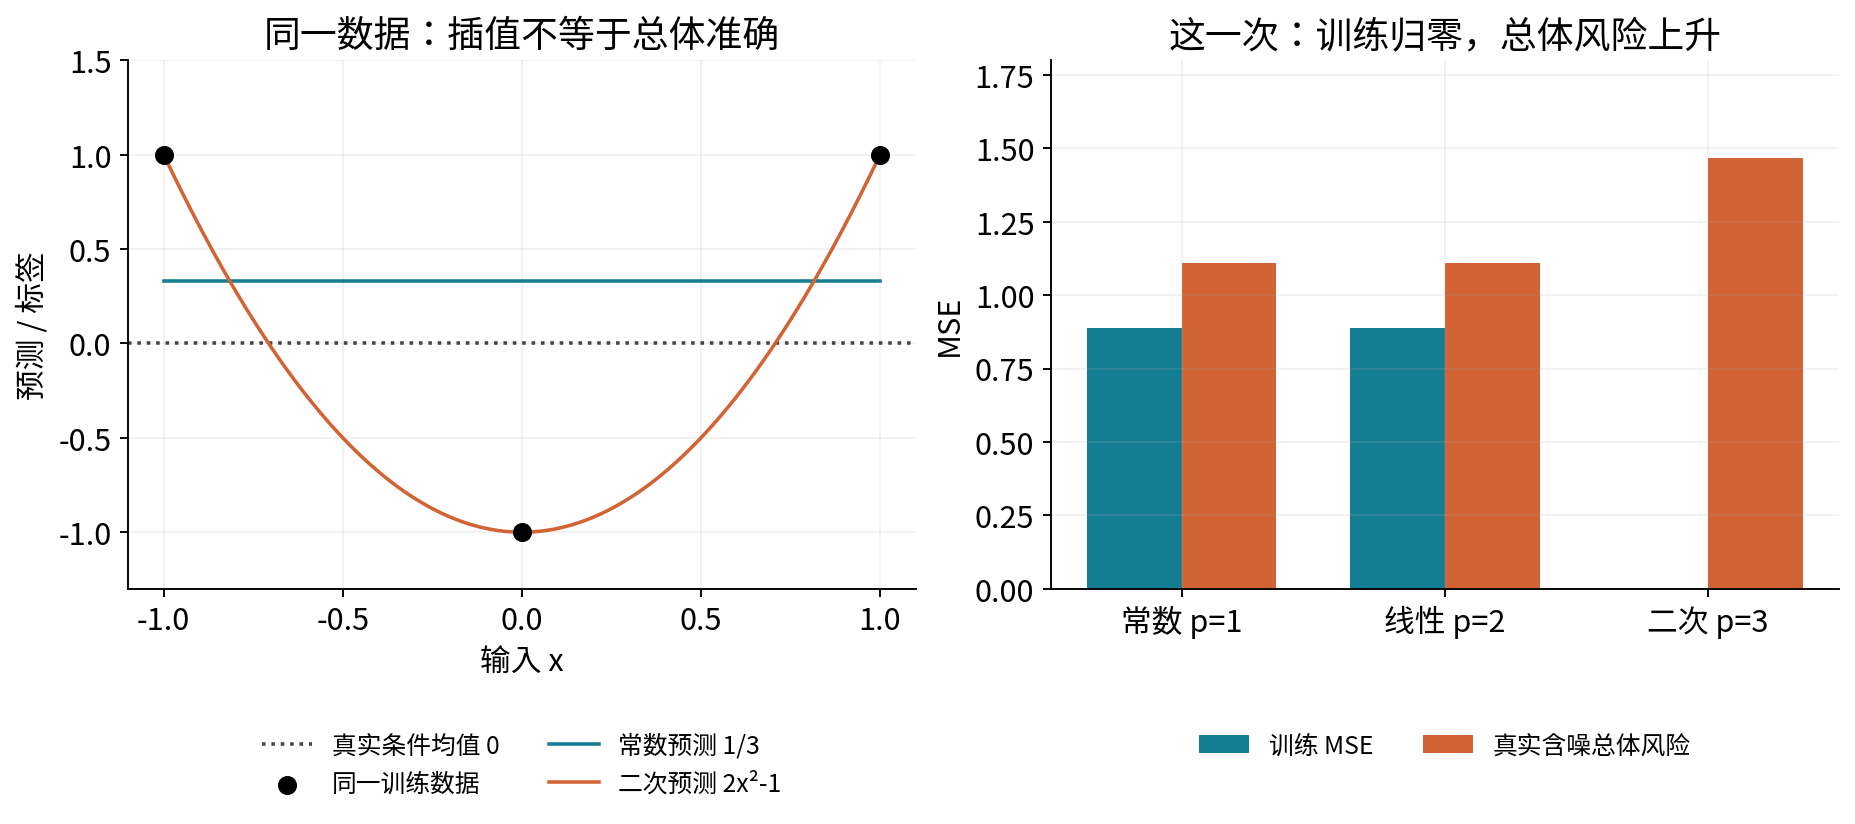

02_exact_enumeration


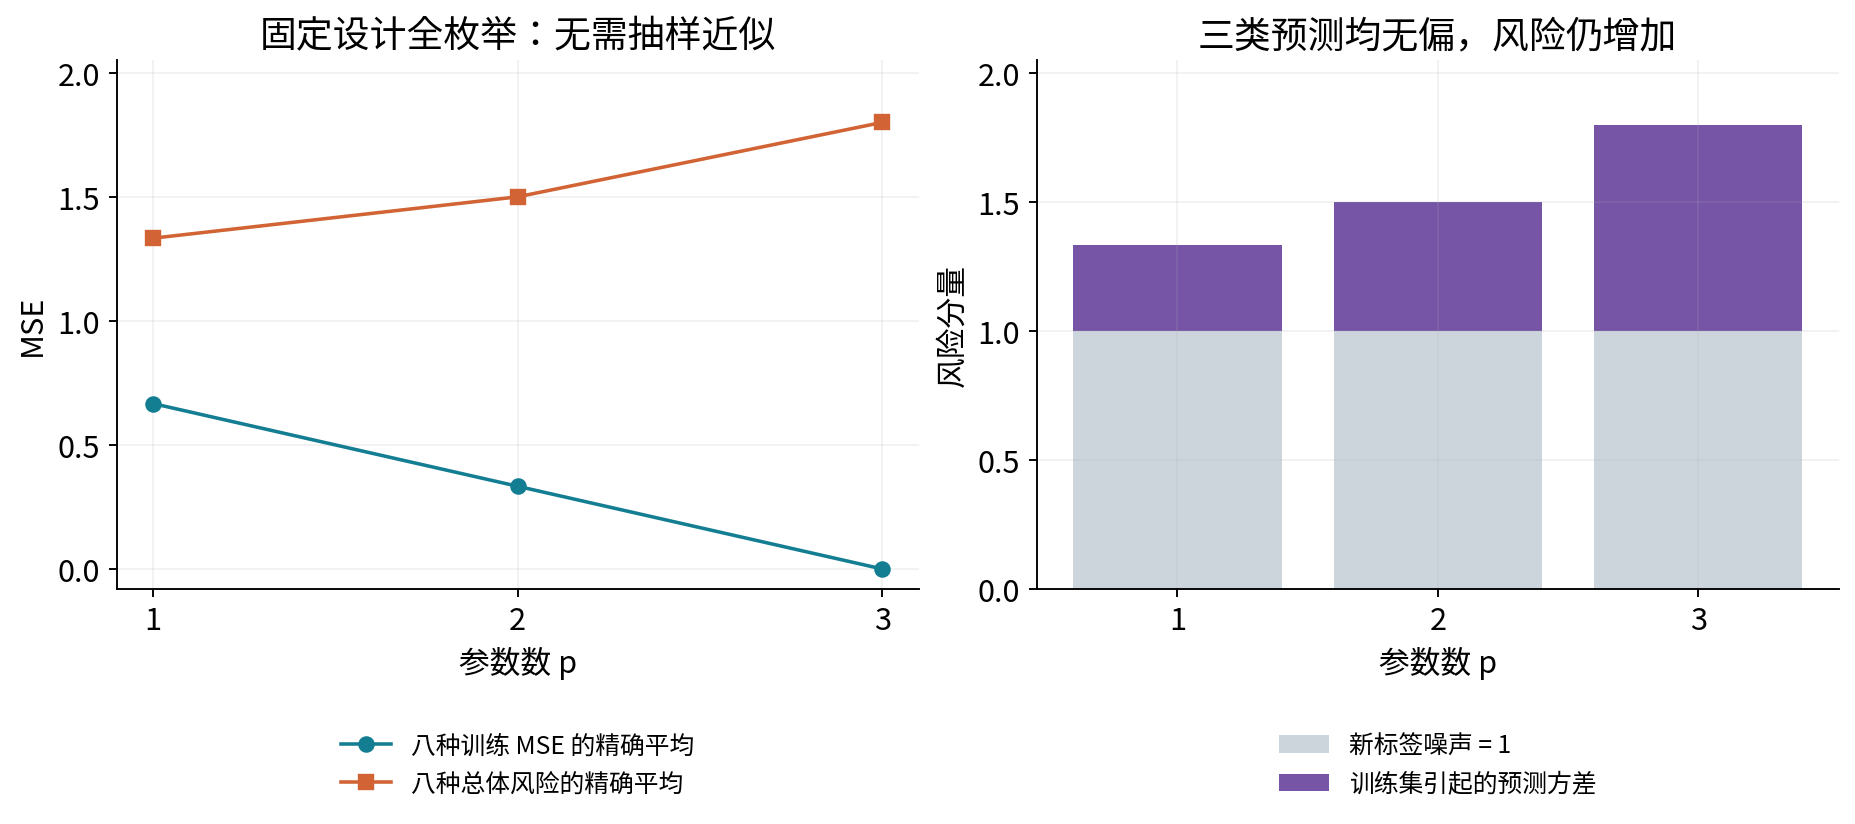

03_complexity


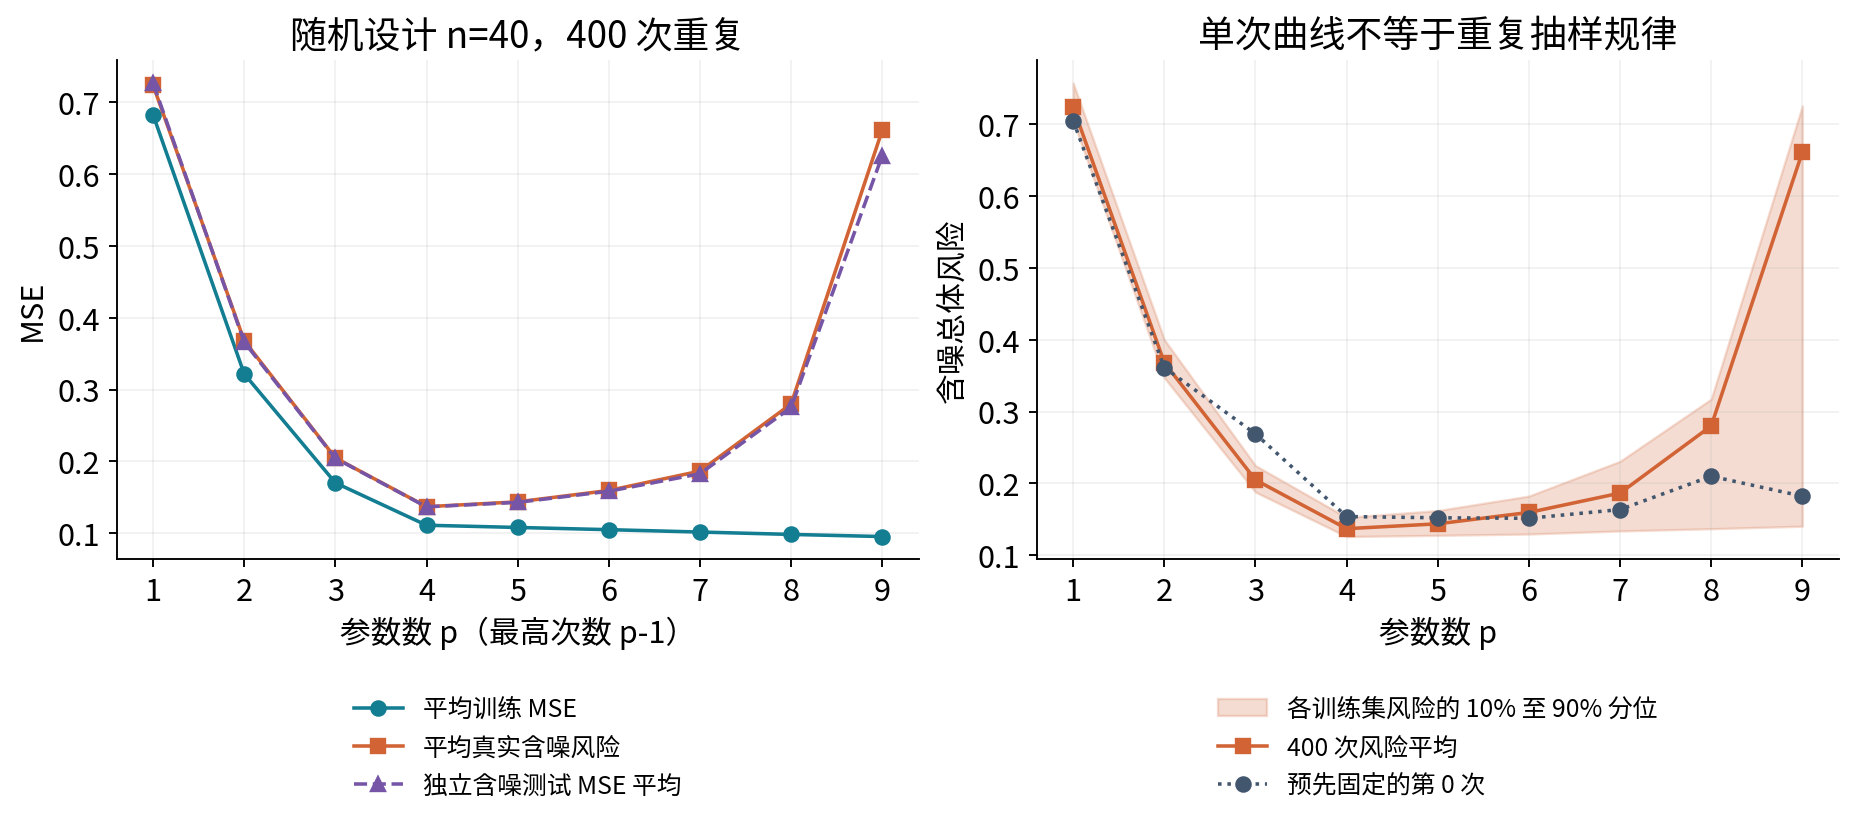

04_bias_variance


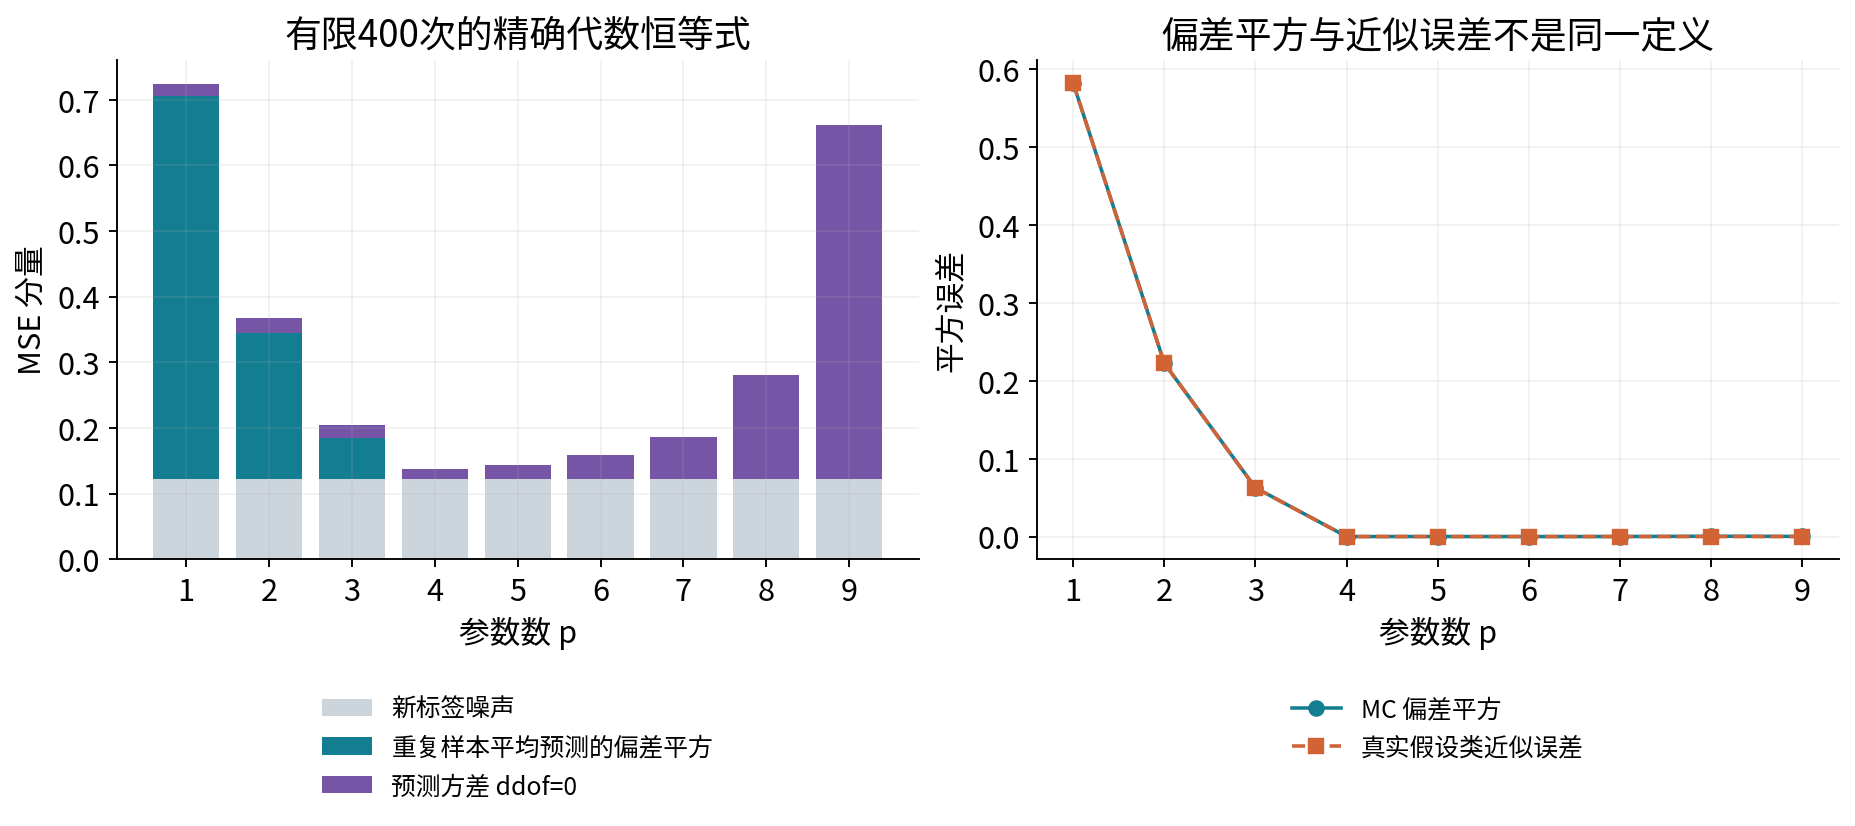

05_learning_curves


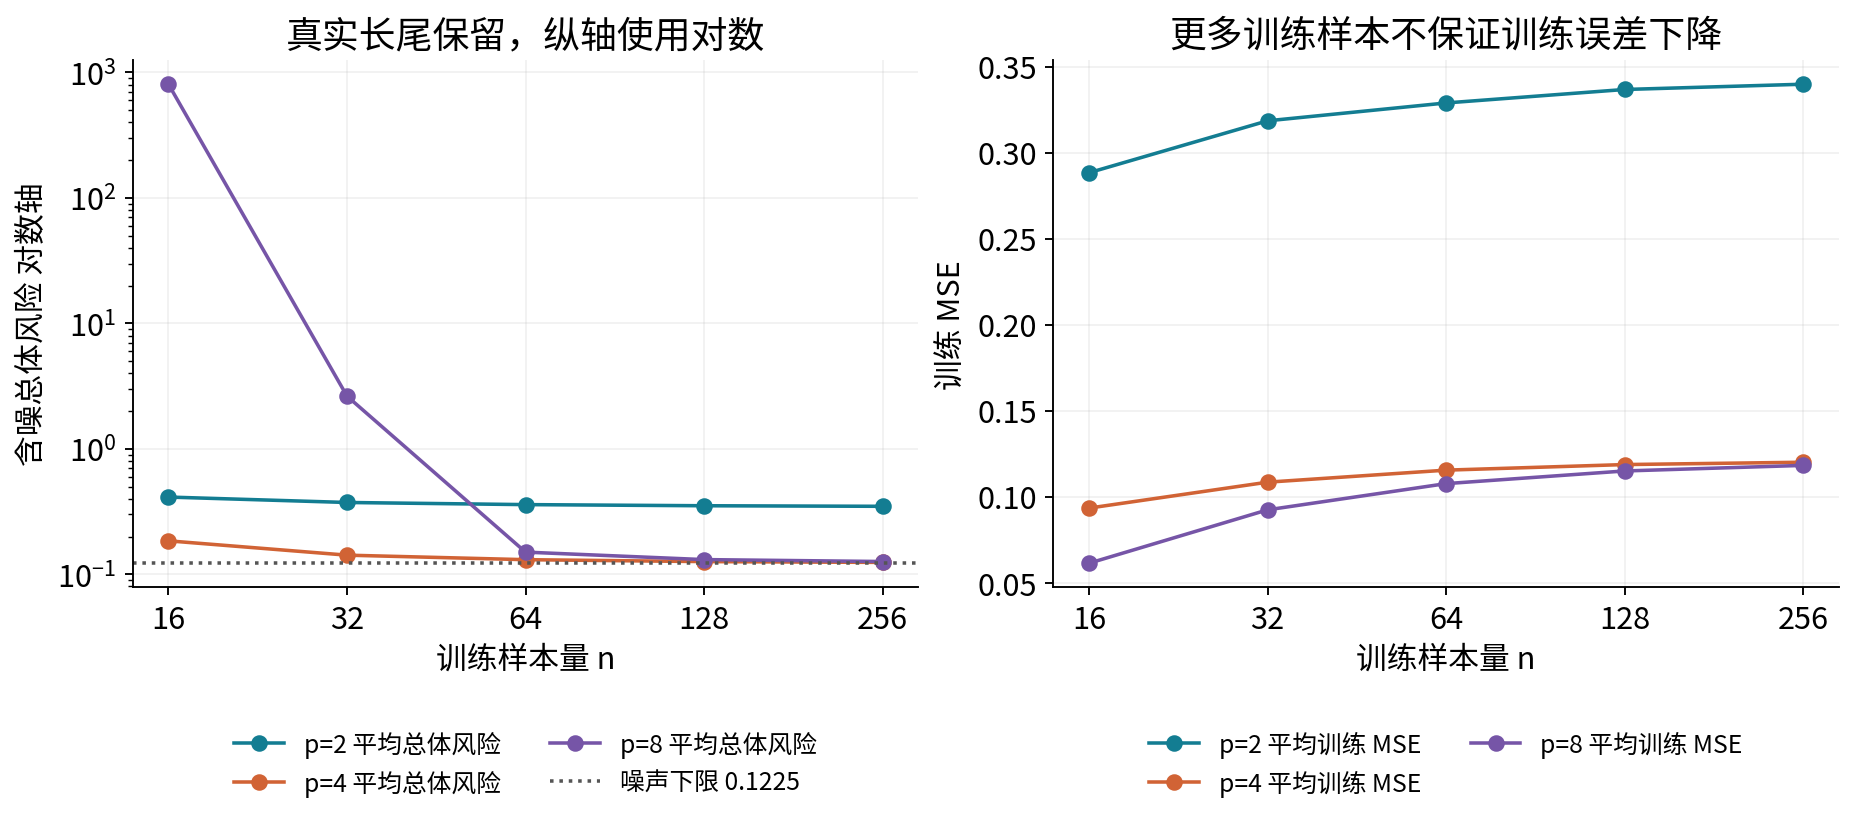

In [10]:
for name in plots.NAMES[:5]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

06_prediction_variability


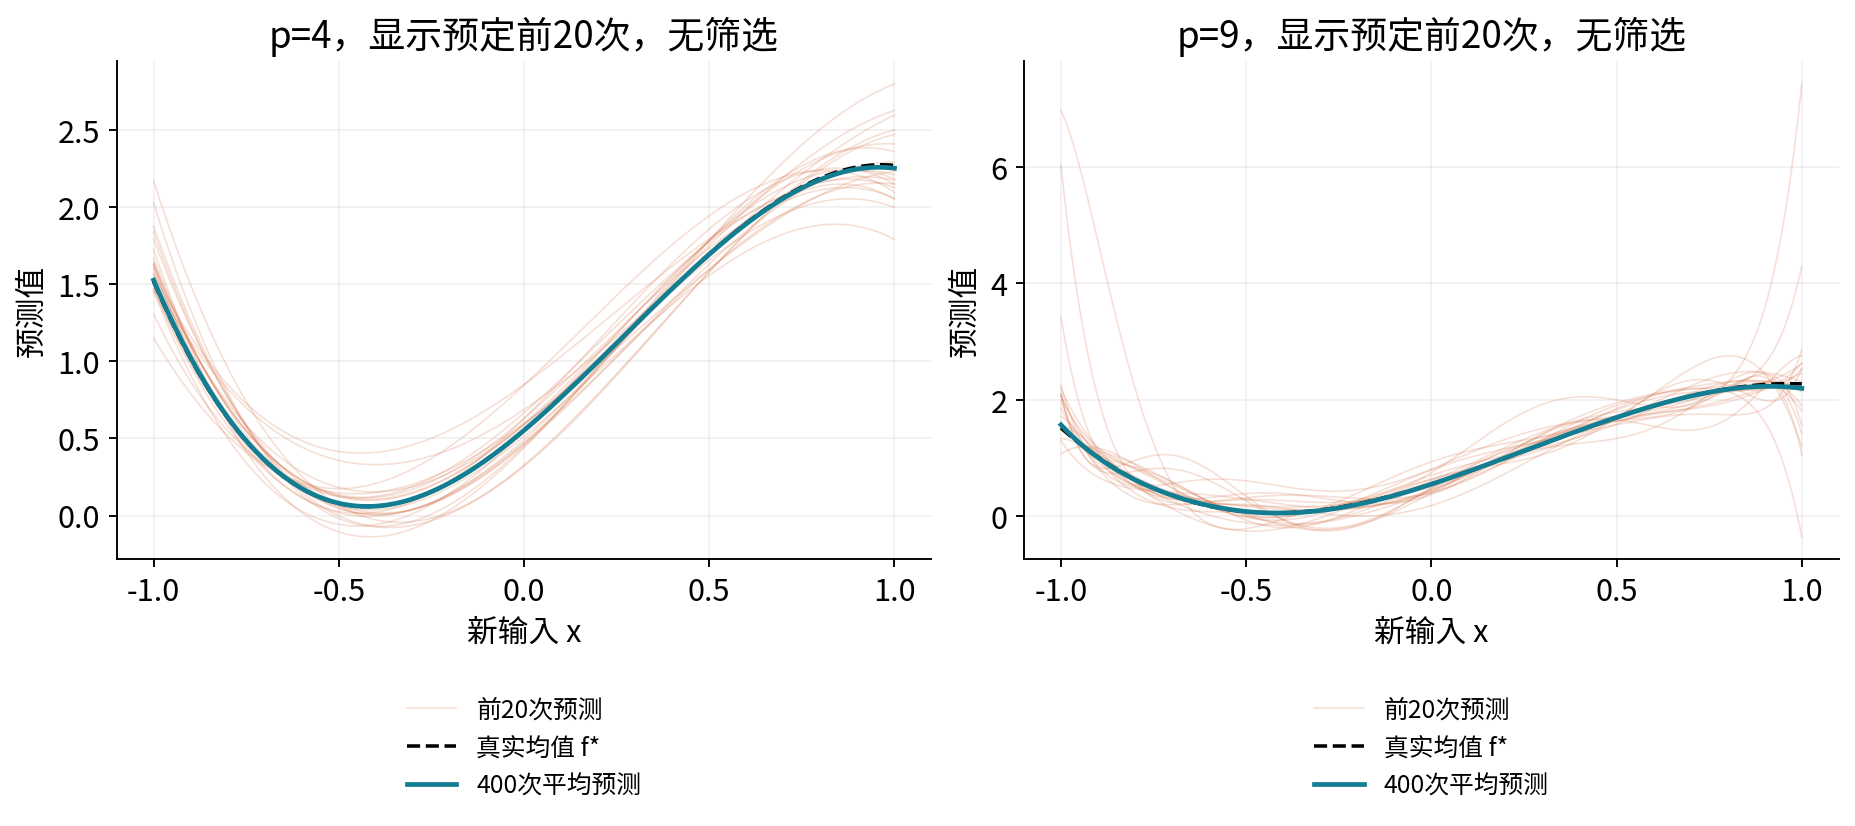

07_risk_distribution


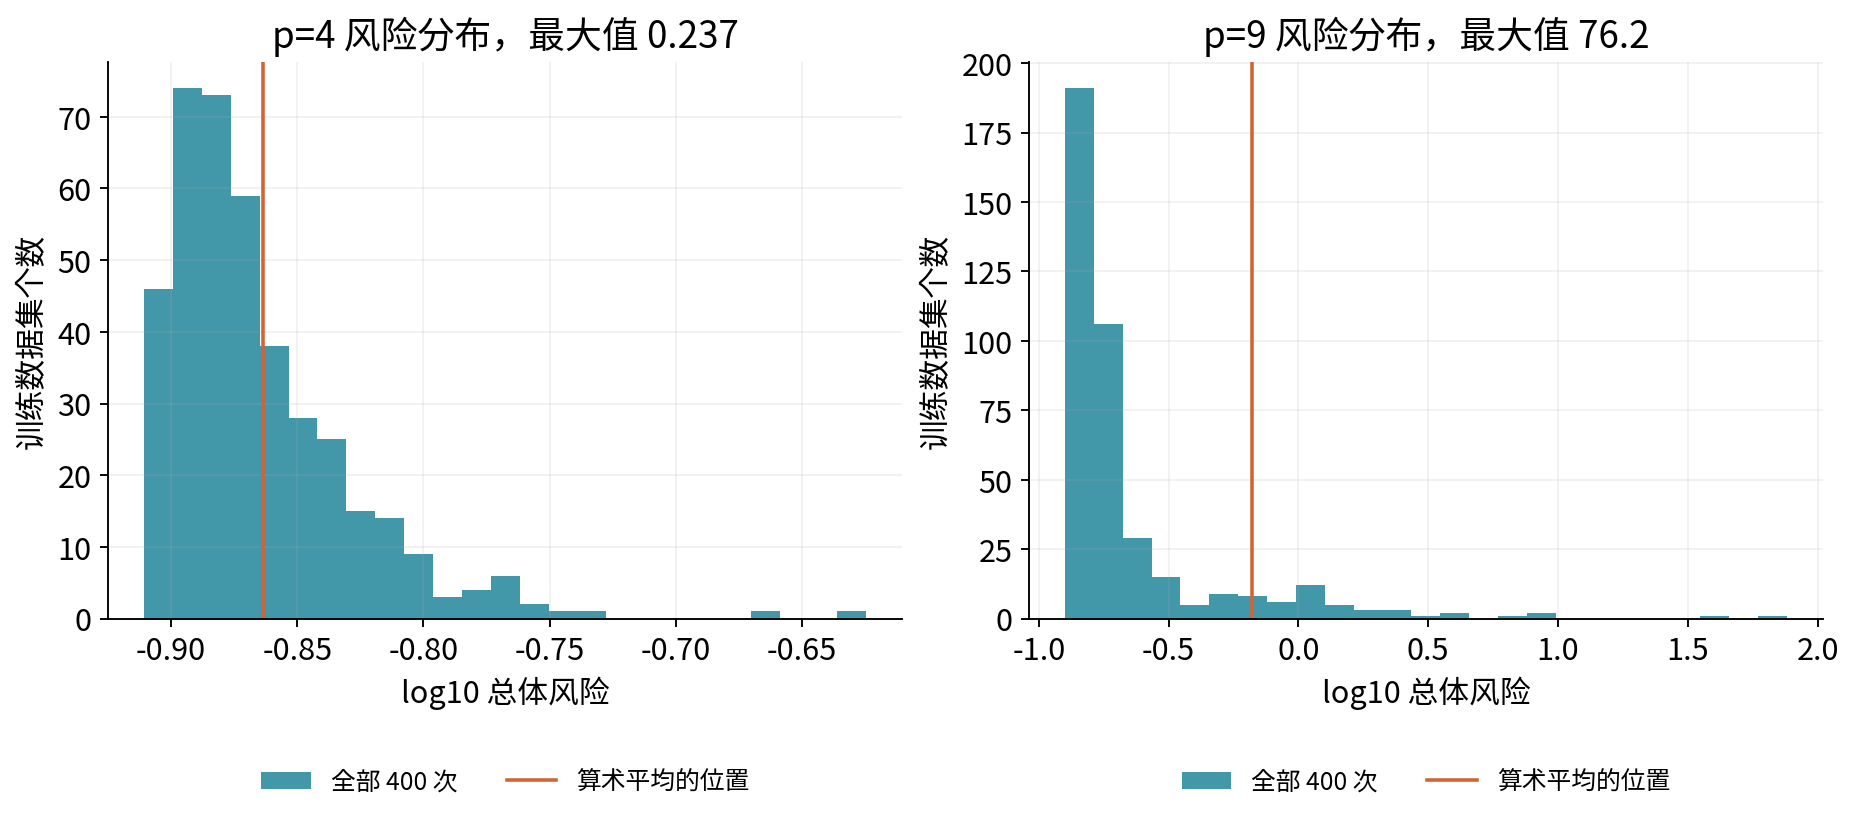

08_fixed_random


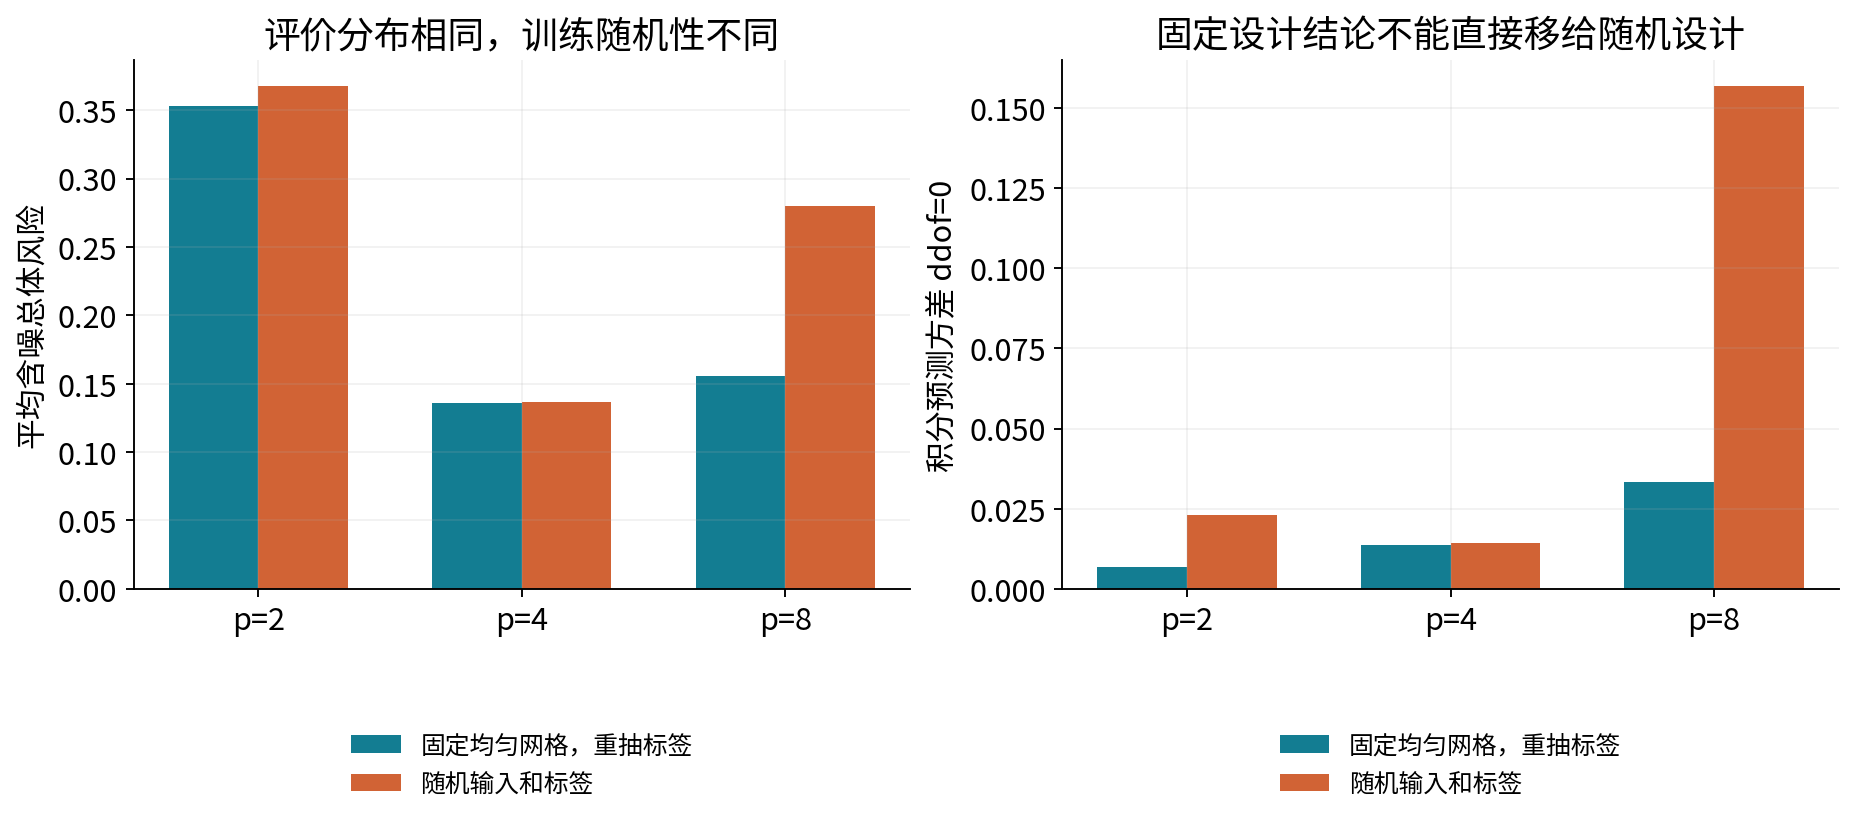

09_test_noise


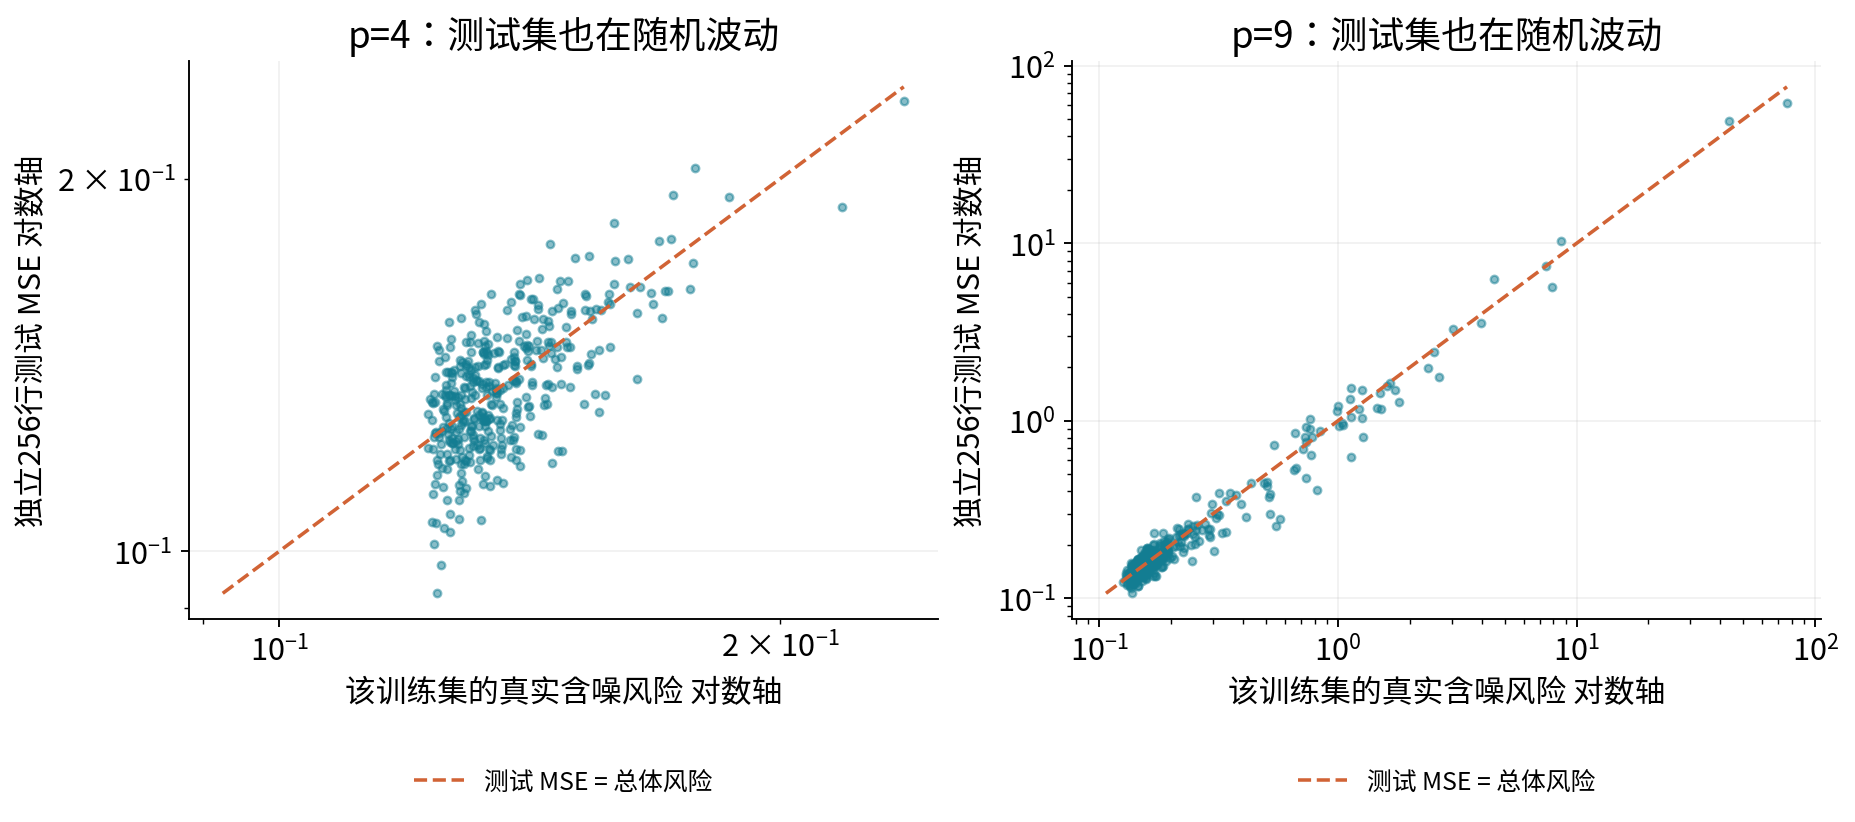

10_ddof_and_bias


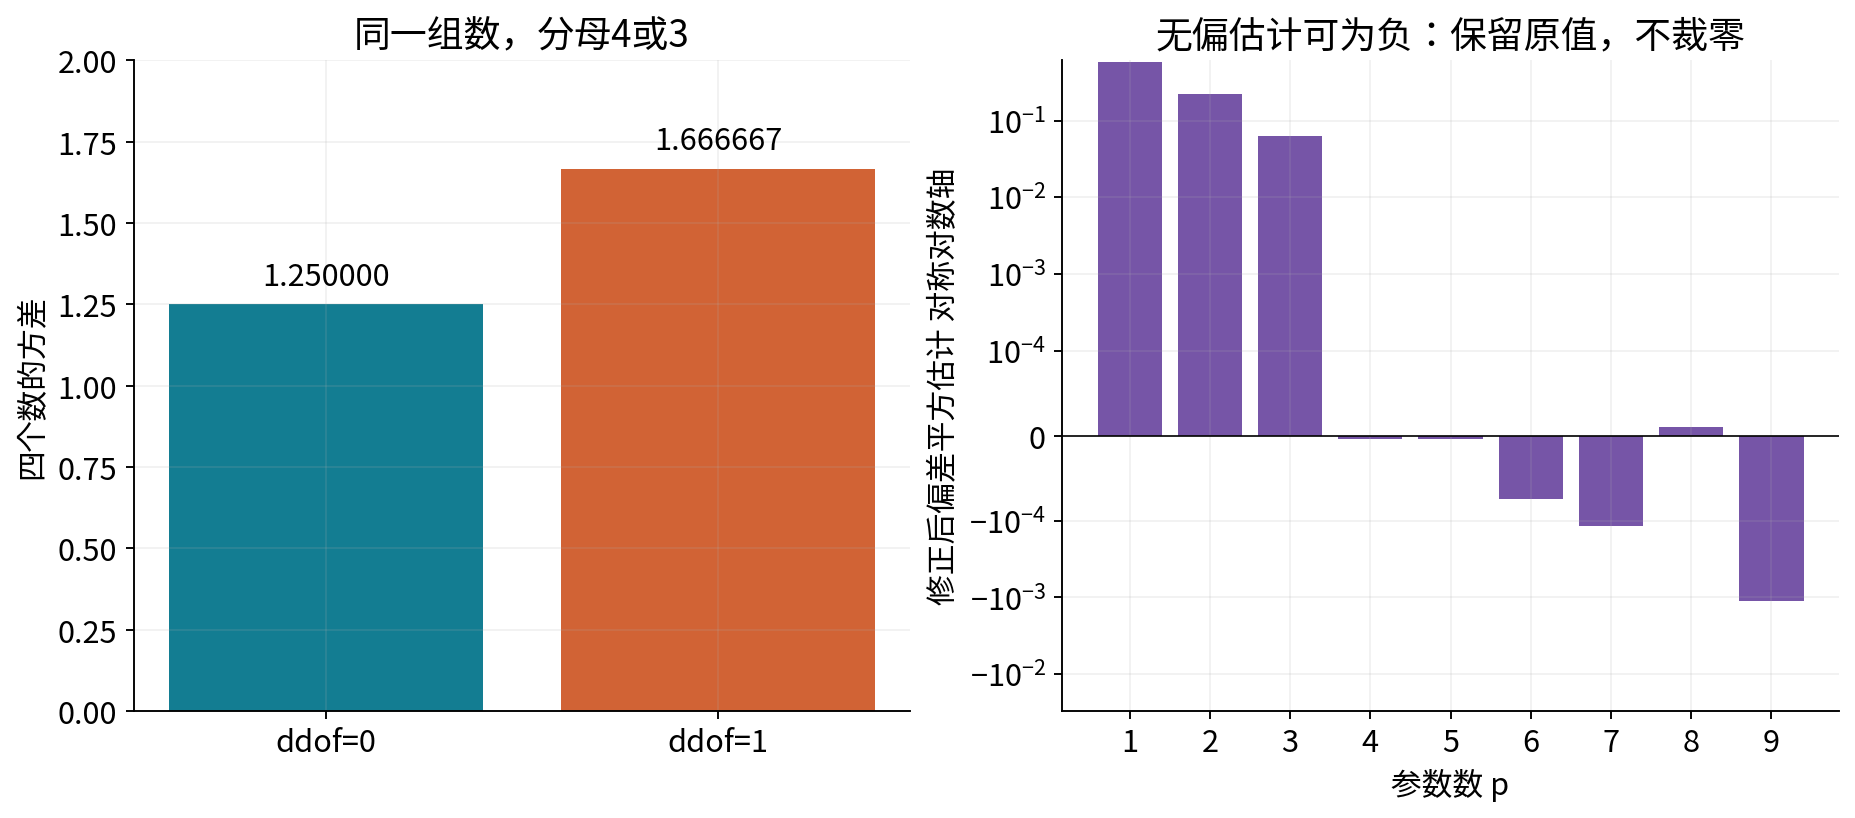

In [11]:
for name in plots.NAMES[5:]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

## 9 读图解释与验收

1. 图1是某个D的风险，图2对八种D精确平均。
2. 随机复杂度曲线p=4均值较低，但该模拟不能决定现实模型的p。
3. p=2近似误差0.2225，加噪声给下限0.345；增加数据不改变类的表达限制。
4. p=8小样本风险大且数值残差小，说明统计误差与优化误差应分别诊断。
5. 10%至90%带会忽略尾部幅度，须一起看全部重复与极值。

在自己的解释中列出固定设计/随机设计、随机对象、评价目标、噪声次数、ddof与矩条件。详细20题解见answers.pdf。

In [12]:
v=np.array([-1.,0.,1.,2.]);B=len(v);bias2=float(v.mean()**2);var0=float(v.var(ddof=0));var1=float(v.var(ddof=1));corrected=bias2-var1/B
print({"mean_square":float(np.mean(v**2)),"bias2":bias2,"var_ddof0":var0,"var_ddof1":var1,"bias2_corrected":corrected,"raw_identity":bias2+var0,"corrected_identity":corrected+var1})
print("Negative tests retained:",result["negative_tests"])

{'mean_square': 1.5, 'bias2': 0.25, 'var_ddof0': 1.25, 'var_ddof1': 1.6666666666666667, 'bias2_corrected': -0.16666666666666669, 'raw_identity': 1.5, 'corrected_identity': 1.5}
Negative tests retained: [{'case': 'rank_deficient', 'status': 'rejected', 'message': 'rank deficient design; no silent fit exclusion'}, {'case': 'n_less_p', 'status': 'rejected', 'message': 'at least p observations required'}, {'case': 'nonfinite', 'status': 'rejected', 'message': 'x must be finite and in [-1,1]'}, {'case': 'outside_domain', 'status': 'rejected', 'message': 'x must be finite and in [-1,1]'}]
